# Análisis bancario

Análisis de transacciones almacenadas en `banco.db`. Incluye:

1. Reporte mensual del monto total de transacciones.
2. Distribución porcentual de transacciones por tipo (gráfica de pastel).
3. Reporte de alertas (transacciones inusualmente altas) exportado a `alertas.xlsx`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('banco.db')
clientes = pd.read_sql_query('SELECT * FROM clientes', conn)
transacciones = pd.read_sql_query('SELECT * FROM transacciones', conn)
transacciones['fecha'] = pd.to_datetime(transacciones['fecha'])
conn.close()

print(f'Clientes: {len(clientes)} | Transacciones: {len(transacciones)}')
transacciones.head()

Clientes: 5 | Transacciones: 200


,id,cliente_id,monto,fecha,tipo
0,1,5,10504.28,2024-11-13,transferencia
1,2,1,14274.17,2024-09-03,retiro
2,3,4,30707.47,2024-09-25,transferencia
3,4,2,1357.28,2024-02-14,retiro
4,5,4,26008.92,2024-12-13,retiro


## Reporte mensual

Monto total de transacciones agrupado por mes.

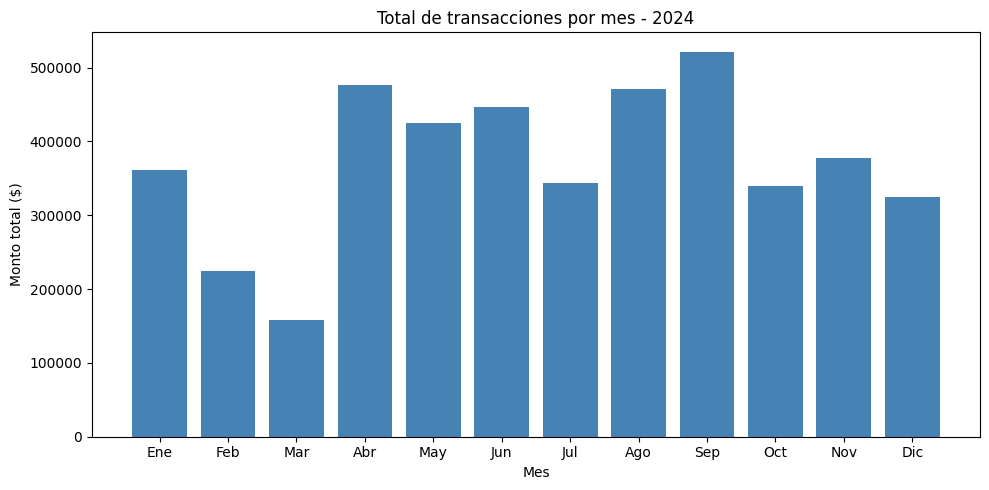

In [2]:
meses_es = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
            'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

mensual = (transacciones
           .assign(mes=transacciones['fecha'].dt.month)
           .groupby('mes')['monto'].sum()
           .reindex(range(1, 13), fill_value=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(meses_es, mensual.values, color='steelblue')
ax.set_title('Total de transacciones por mes - 2024')
ax.set_xlabel('Mes')
ax.set_ylabel('Monto total ($)')
fig.tight_layout()
fig.savefig('reporte_mensual.png', dpi=100)
plt.show()

## Distribución porcentual por tipo de transacción

Gráfica de pastel con el porcentaje de transacciones por tipo (depósito, retiro, transferencia).

tipo
transferencia    71
depósito         67
retiro           62
Name: count, dtype: int64


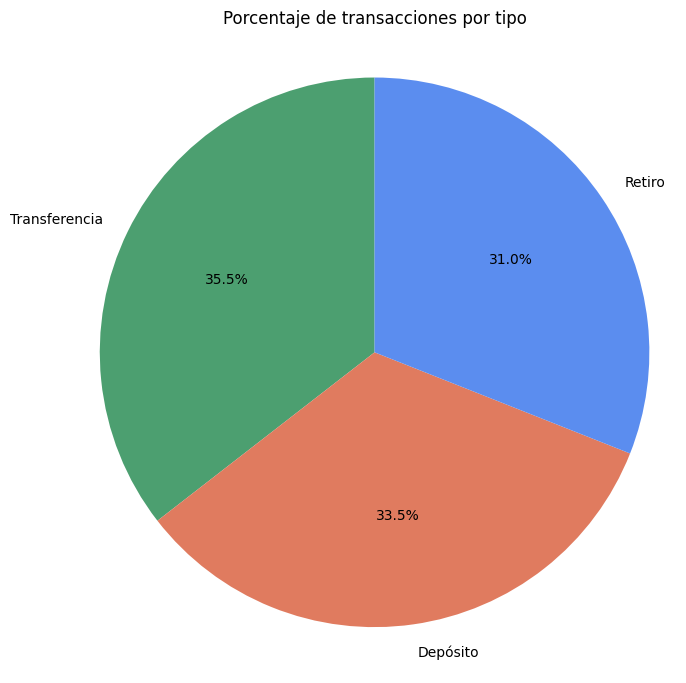

In [3]:
por_tipo = transacciones['tipo'].value_counts()
print(por_tipo)

fig, ax = plt.subplots(figsize=(7, 7))
colores = ['#4C9F70', '#E07B5F', '#5B8DEF']
ax.pie(
    por_tipo.values,
    labels=[t.capitalize() for t in por_tipo.index],
    autopct='%1.1f%%',
    colors=colores[:len(por_tipo)],
    startangle=90,
)
ax.set_title('Porcentaje de transacciones por tipo')
ax.axis('equal')
fig.tight_layout()
fig.savefig('reporte_tipos.png', dpi=100)
plt.show()

## Reporte de alertas

Se consideran alertas las transacciones cuyo monto supera dos veces la desviación estándar sobre el promedio. El reporte se exporta a `alertas.xlsx`.

In [4]:
umbral = transacciones['monto'].quantile(0.9)
print(f'Umbral de alerta (percentil 90): ${umbral:,.2f}')

alertas = (transacciones
           .merge(clientes, left_on='cliente_id', right_on='id',
                  suffixes=('', '_cliente'))
           .query('monto > @umbral')
           .loc[:, ['id', 'fecha', 'nombre', 'tipo_cuenta', 'tipo', 'monto']]
           .rename(columns={'id': 'transaccion_id', 'nombre': 'cliente'})
           .sort_values('monto', ascending=False)
           .reset_index(drop=True))

alertas.to_excel('alertas.xlsx', index=False, sheet_name='Alertas')
print(f'Alertas generadas: {len(alertas)} (archivo: alertas.xlsx)')
alertas.head(10)

Umbral de alerta (percentil 90): $41,510.70


Alertas generadas: 20 (archivo: alertas.xlsx)


,transaccion_id,fecha,cliente,tipo_cuenta,tipo,monto
0,73,2024-01-30,Carlos Pérez,Corriente,transferencia,49925.85
1,198,2024-06-21,Luis Martínez,Corriente,depósito,49893.45
2,111,2024-05-12,Sofia Ruiz,Ahorro,transferencia,49346.35
3,70,2024-09-06,Luis Martínez,Corriente,transferencia,49023.92
4,103,2024-08-03,Ana García,Ahorro,transferencia,48750.48
5,46,2024-05-27,Carlos Pérez,Corriente,retiro,48442.11
6,42,2024-09-08,Carlos Pérez,Corriente,depósito,47502.75
7,151,2024-08-17,María López,Ahorro,depósito,46883.32
8,163,2024-01-15,Luis Martínez,Corriente,transferencia,46701.24
9,28,2024-10-15,Luis Martínez,Corriente,depósito,46540.76
